#EDA

##Importacion de librerias

In [32]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

##Análisis exploratorio

In [33]:
df = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/main/data/dataset_bruto_final.csv")

print("="*70)
print("1. EDA - RESUMEN GENERAL")
print("="*70)
print(f"Dimensiones: {df.shape}")
print(f"\nValores nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"\nDistribución de la variable objetivo (categoria):")
print(df["categoria"].value_counts())

# --- Hallazgo crítico de EDA: fuga de datos (data leakage) ---
# 'energy_efficiency_score' separa las clases de forma casi perfecta y sin
# solapamiento (Inefficient: 0-25.3 | Moderate: 25.4-52.6 | Efficient: 52.7-100).
# Esto sugiere que 'categoria' fue derivada directamente de esta columna
# mediante umbrales. Si se usa como feature, el modelo "hace trampa" (accuracy
# ~100% trivial, sin valor predictivo real). Se EXCLUYE del modelado.
print("\n--- Chequeo de leakage: energy_efficiency_score por categoria ---")
print(df.groupby("categoria")["energy_efficiency_score"].describe()[["min", "max"]])

# --- Segundo hallazgo: costo_estimado es 100% redundante con consumo_kwh ---
# costo_estimado = consumo_kwh * tarifa_kwh (diferencia ~0), y tarifa_kwh es
# constante (0.75) para todas las filas -> ambas columnas se descartan.
diff = (df["costo_estimado"] - df["consumo_kwh"] * df["tarifa_kwh"]).abs().max()
print(f"\nDiferencia max costo_estimado vs consumo*tarifa: {diff:.6f} (≈0 -> redundante)")
print(f"Valores únicos de tarifa_kwh: {df['tarifa_kwh'].nunique()} (constante -> sin valor predictivo)")

1. EDA - RESUMEN GENERAL
Dimensiones: (10000, 33)

Valores nulos por columna:
antiguedad_vivienda             454
horas_en_casa                   287
ingreso_mensual                 435
electrodomesticos_eficientes    273
dtype: int64

Filas duplicadas: 0

Distribución de la variable objetivo (categoria):
categoria
Moderate       4495
Efficient      3003
Inefficient    2502
Name: count, dtype: int64

--- Chequeo de leakage: energy_efficiency_score por categoria ---
              min    max
categoria               
Efficient    52.7  100.0
Inefficient   0.0   25.3
Moderate     25.4   52.6

Diferencia max costo_estimado vs consumo*tarifa: 0.000000 (≈0 -> redundante)
Valores únicos de tarifa_kwh: 1 (constante -> sin valor predictivo)


#ETL

##Limpieza y transformación

In [34]:
print("\n" + "="*70)
print("2. ETL")
print("="*70)

# 2.1 Imputación de nulos (mediana, robusta a outliers)
cols_nulas = ["antiguedad_vivienda", "horas_en_casa", "ingreso_mensual", "electrodomesticos_eficientes"]
for c in cols_nulas:
    df[c] = df[c].fillna(df[c].median())
print(f"Nulos imputados con mediana en: {cols_nulas}")

# 2.2 Booleanos a enteros (0/1)
bool_cols = ["paneles_solares", "trabajo_remoto", "calefaccion", "uso_horario_pico"]
for c in bool_cols:
    df[c] = df[c].astype(int)

# 2.3 Codificación ORDINAL para variables con orden natural
# (usar one-hot aquí perdería la información de orden: Poor < Average < Good < Excellent)
df["aislamiento_enc"] = df["aislamiento"].map({"Poor": 0, "Average": 1, "Good": 2, "Excellent": 3})
df["eficiencia_construccion_enc"] = df["eficiencia_construccion"].map({"E": 0, "D": 1, "C": 2, "B": 3, "A": 4})

# 2.4 Codificación ONE-HOT para variables nominales (sin orden natural)
df = pd.get_dummies(df, columns=["tipo_calefaccion", "tipo_iluminacion"], drop_first=True)

# 2.5 Codificar target
le_y = LabelEncoder()
y = le_y.fit_transform(df["categoria"])
print(f"Clases codificadas: {dict(zip(le_y.classes_, range(len(le_y.classes_))))}")


2. ETL
Nulos imputados con mediana en: ['antiguedad_vivienda', 'horas_en_casa', 'ingreso_mensual', 'electrodomesticos_eficientes']
Clases codificadas: {'Efficient': 0, 'Inefficient': 1, 'Moderate': 2}


In [35]:
# 2.6 Guardar dataset limpio (post-ETL) para descarga / trazabilidad
os.makedirs("/content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/data", exist_ok=True)
RUTA_DATASET_LIMPIO = "/content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/data/dataset_limpio_modeloknn.csv"
df.to_csv(RUTA_DATASET_LIMPIO, index=False)
print(f"\nDataset limpio (post-ETL) guardado en: {RUTA_DATASET_LIMPIO}")


Dataset limpio (post-ETL) guardado en: /content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/data/dataset_limpio_modeloknn.csv


#MODELADO KNN

##Selección de variables

In [36]:
print("\n" + "="*70)
print("3. SELECCIÓN DE VARIABLES POR MUTUAL INFORMATION")
print("="*70)

candidate_cols = [
    "metros_cuadrados", "habitaciones", "baños", "antiguedad_vivienda", "aislamiento_enc",
    "eficiencia_construccion_enc", "paneles_solares", "cantidad_personas", "trabajo_remoto",
    "horas_en_casa", "ingreso_mensual", "aires_acondicionados", "heladeras", "televisores",
    "computadoras", "lavadoras", "secadoras", "cantidad_equipos", "calefaccion",
    "electrodomesticos_eficientes", "temperatura_media", "consumo_kwh", "uso_horario_pico",
    "horas_alto_consumo",
] + [c for c in df.columns if c.startswith("tipo_iluminacion_") or c.startswith("tipo_calefaccion_")]

mi_scores = mutual_info_classif(df[candidate_cols], y, random_state=RANDOM_STATE)
mi_ranking = pd.Series(mi_scores, index=candidate_cols).sort_values(ascending=False)
print(mi_ranking)

# Variables ganadoras: las de mayor mutual information con la categoria
TOP_FEATURES = [
    "aislamiento_enc", "eficiencia_construccion_enc", "antiguedad_vivienda",
    "electrodomesticos_eficientes", "cantidad_personas", "consumo_kwh",
    "horas_en_casa", "trabajo_remoto",
] + [c for c in df.columns if c.startswith("tipo_iluminacion_") or c.startswith("tipo_calefaccion_")]

print(f"\nFeatures seleccionadas ({len(TOP_FEATURES)}): {TOP_FEATURES}")


3. SELECCIÓN DE VARIABLES POR MUTUAL INFORMATION
aislamiento_enc                   0.229129
eficiencia_construccion_enc       0.115839
antiguedad_vivienda               0.107664
electrodomesticos_eficientes      0.072003
tipo_iluminacion_LED              0.064358
tipo_calefaccion_Gas              0.040734
cantidad_personas                 0.025343
consumo_kwh                       0.022945
horas_en_casa                     0.021541
trabajo_remoto                    0.020376
heladeras                         0.016271
paneles_solares                   0.014405
horas_alto_consumo                0.011819
metros_cuadrados                  0.009737
tipo_iluminacion_Mixta            0.007313
habitaciones                      0.006521
calefaccion                       0.005981
uso_horario_pico                  0.005236
computadoras                      0.004992
lavadoras                         0.003405
tipo_calefaccion_Losa Radiante    0.001018
aires_acondicionados              0.000000
ingr

##Division y Escalado

In [37]:
X = df[TOP_FEATURES]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



##GRIDSEARCHCV

In [38]:
print("\n" + "="*70)
print("5. GRIDSEARCHCV")
print("="*70)

param_grid = {
    "n_neighbors": list(range(5, 32, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro",  # f1_macro en vez de accuracy: las clases están algo desbalanceadas
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)
best_knn = grid_search.best_estimator_
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1-macro en CV: {grid_search.best_score_:.4f}")


5. GRIDSEARCHCV
Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Mejor F1-macro en CV: 0.7906


##Evaluacion final

In [39]:
# =============================================================================
# 6. EVALUACIÓN FINAL
# =============================================================================
print("\n" + "="*70)
print("6. RESULTADOS EN TEST")
print("="*70)
y_pred = best_knn.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1-macro: {test_f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_))

baseline = pd.Series(y).value_counts(normalize=True).max()
print(f"Baseline (predecir siempre clase mayoritaria): {baseline:.4f}")
print(f"Mejora sobre baseline: +{(test_accuracy - baseline)*100:.1f} puntos")


6. RESULTADOS EN TEST
Accuracy: 0.7885
F1-macro: 0.7898

Reporte de clasificación:
              precision    recall  f1-score   support

   Efficient       0.85      0.80      0.82       601
 Inefficient       0.82      0.73      0.77       500
    Moderate       0.74      0.82      0.78       899

    accuracy                           0.79      2000
   macro avg       0.80      0.78      0.79      2000
weighted avg       0.79      0.79      0.79      2000

Baseline (predecir siempre clase mayoritaria): 0.4495
Mejora sobre baseline: +33.9 puntos


##Visualizaciones

In [45]:
import os

# =============================================================================
# 7. VISUALIZACIONES
# =============================================================================

# Crear el directorio para guardar las imágenes si no existe
charts_dir = "/content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/visualizaciones"
os.makedirs(charts_dir, exist_ok=True)
print(f"Directorio de gráficos: {charts_dir}")



Directorio de gráficos: /content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/visualizaciones


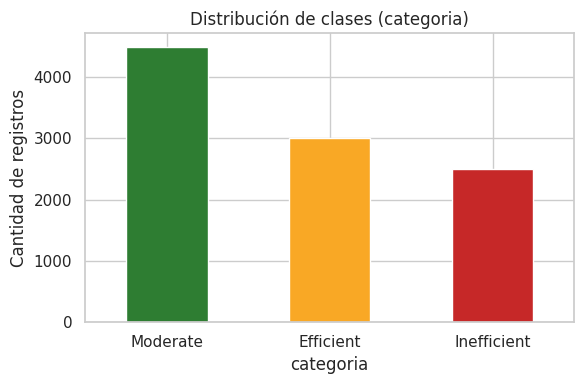

In [46]:
# 7.1 Balance de clases
fig, ax = plt.subplots(figsize=(6, 4))
df["categoria"].value_counts().plot(kind="bar", color=["#2E7D32", "#F9A825", "#C62828"], ax=ax)
ax.set_title("Distribución de clases (categoria)")
ax.set_ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "01_balance_clases.png"), dpi=120)
plt.show()

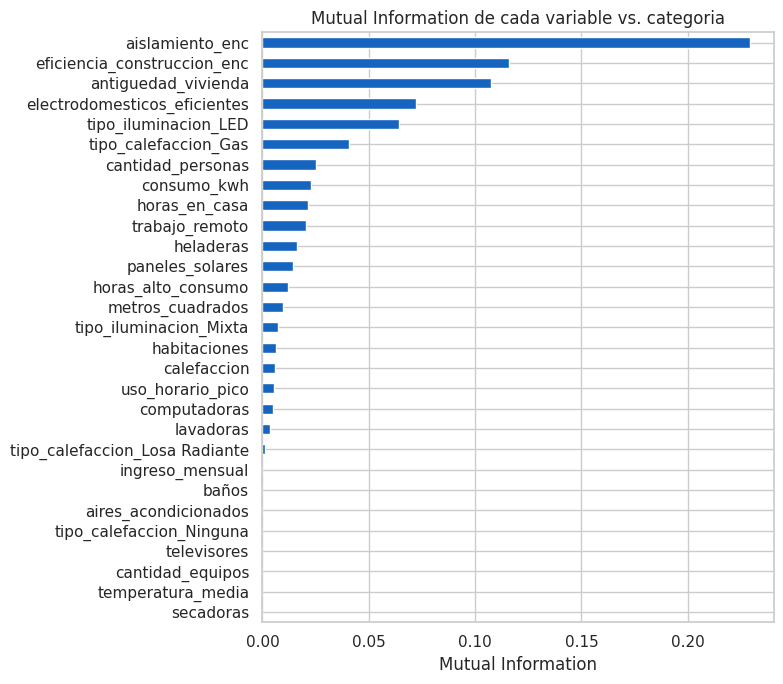

In [47]:
# 7.2 Mutual information ranking
fig, ax = plt.subplots(figsize=(8, 7))
mi_ranking.sort_values().plot(kind="barh", color="#1565C0", ax=ax)
ax.set_title("Mutual Information de cada variable vs. categoria")
ax.set_xlabel("Mutual Information")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "02_mutual_information.png"), dpi=120)
plt.show()


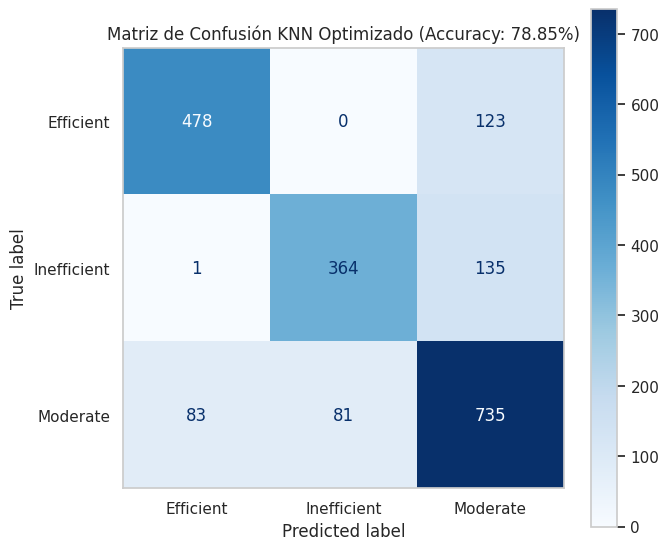

In [48]:
# 7.3 Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le_y.classes_, cmap="Blues", ax=ax
)
plt.title(f"Matriz de Confusión KNN Optimizado (Accuracy: {test_accuracy:.2%})")
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "03_matriz_confusion.png"), dpi=120)
plt.show()



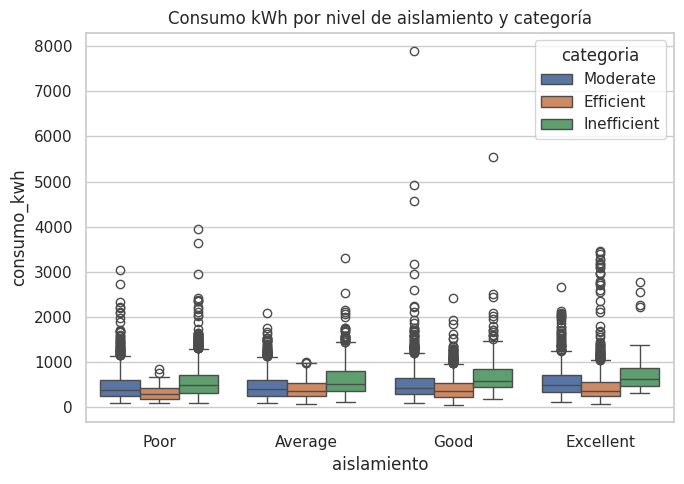

In [49]:
# 7.4 Boxplot de la variable más predictiva (aislamiento) vs categoria
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="aislamiento", y="consumo_kwh", hue="categoria",
            order=["Poor", "Average", "Good", "Excellent"], ax=ax)
ax.set_title("Consumo kWh por nivel de aislamiento y categoría")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "04_aislamiento_vs_categoria.png"), dpi=120)
plt.show()


##Conclusión del modelo

Configuración óptima (GridSearchCV): n_neighbors=21, weights=distance, metric=manhattan → F1-macro en validación cruzada de 0.79.

Resultados en test (2,000 registros, nunca vistos por el modelo):

Métrica	Valor
Accuracy	78.9%
F1-macro	79.0%
Baseline (clase mayoritaria)	45.0%
Mejora sobre baseline	+33.9 puntos

Por clase:

Efficient: precision 0.85 / recall 0.80 — el modelo la identifica muy bien y con pocos falsos positivos.
Inefficient: precision 0.82 / recall 0.73 — es la clase más difícil de "atrapar" (recall más bajo); cuando la predice, acierta casi siempre, pero se le escapan algunos casos reales hacia "Moderate".
Moderate: precision 0.74 / recall 0.82 — es la clase "cajón de sastre": buen recall pero menor precisión, porque absorbe confusiones tanto de Efficient como de Inefficient (tiene sentido, al ser la categoría intermedia).

Efectividad general: el modelo es claramente útil, casi duplica el desempeño del baseline ingenuo (79% vs 45%), lo cual es un salto real y no trivial. El hecho de que el F1-macro de test (0.79) esté muy alineado con el de validación cruzada (0.79) indica que no hay overfitting — generaliza bien a datos nuevos.

Qué explica la predicción: el ranking de mutual information confirma que la eficiencia se explica sobre todo por variables estructurales de la vivienda (aislamiento, eficiencia constructiva, antigüedad) más que por el comportamiento del hogar (consumo_kwh, horas en casa aportan mucho menos). Esto es coherente y le da sentido físico al modelo, no solo estadístico.

Limitación honesta: la confusión se concentra en la frontera Inefficient↔Moderate y Efficient↔Moderate — errores "vecinos" (nunca confunde Efficient con Inefficient directamente), lo cual es el tipo de error menos grave posible en este contexto.

Veredicto: el KNN es un modelo sólido y confiable para uso práctico (ej. priorizar viviendas para auditorías energéticas o programas de eficiencia), aunque si se necesita mayor precisión en el límite Inefficient/Moderate convendría probar un modelo basado en árboles (Random Forest/XGBoost) para comparar.

#Serialización

In [50]:
# =============================================================================
# 8. SERIALIZACIÓN DEL MODELO Y ARTEFACTOS DE PREPROCESAMIENTO
# =============================================================================

print("\n" + "="*70)
print("8. SERIALIZACIÓN")
print("="*70)

DIR_MODELO = "/content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/archivos_pkl"
os.makedirs(DIR_MODELO, exist_ok=True)


8. SERIALIZACIÓN


In [51]:
# 8.1 Serializar por separado (uso individual / debugging)
joblib.dump(best_knn, os.path.join(DIR_MODELO, "knn_model.pkl"))
joblib.dump(scaler, os.path.join(DIR_MODELO, "scaler.pkl"))
joblib.dump(le_y, os.path.join(DIR_MODELO, "label_encoder.pkl"))
joblib.dump(TOP_FEATURES, os.path.join(DIR_MODELO, "features.pkl"))
joblib.dump(list(X_train.columns), os.path.join(DIR_MODELO, "model_columns.pkl"))

['/content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/archivos_pkl/model_columns.pkl']

In [52]:
# 8.2 Serializar todo junto en un único artefacto (uso en producción/inferencia)
pipeline_artifact = {
    "model": best_knn,
    "scaler": scaler,
    "label_encoder": le_y,
    "features": TOP_FEATURES,
    "model_columns": list(X_train.columns),
    "best_params": grid_search.best_params_,
    "test_accuracy": test_accuracy,
    "test_f1_macro": test_f1,
}

RUTA_PIPELINE = os.path.join(DIR_MODELO, "pipeline_completo.pkl")
joblib.dump(pipeline_artifact, RUTA_PIPELINE)

print(f"Modelo KNN serializado en:        {os.path.join(DIR_MODELO, 'knn_model.pkl')}")
print(f"Scaler serializado en:            {os.path.join(DIR_MODELO, 'scaler.pkl')}")
print(f"LabelEncoder serializado en:      {os.path.join(DIR_MODELO, 'label_encoder.pkl')}")
print(f"Lista de features serializada en: {os.path.join(DIR_MODELO, 'features.pkl')}")
print(f"Columnas del modelo serializadas en: {os.path.join(DIR_MODELO, 'model_columns.pkl')}")
print(f"Pipeline completo (todo-en-uno):  {RUTA_PIPELINE}")

Modelo KNN serializado en:        /content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/archivos_pkl/knn_model.pkl
Scaler serializado en:            /content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/archivos_pkl/scaler.pkl
LabelEncoder serializado en:      /content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/archivos_pkl/label_encoder.pkl
Lista de features serializada en: /content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/archivos_pkl/features.pkl
Columnas del modelo serializadas en: /content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/archivos_pkl/model_columns.pkl
Pipeline completo (todo-en-uno):  /content/drive/MyDrive/Hackathon_EnergyIA/Notebooks/MODELO KNN/Accuracy_0.789/archivos_pkl/pipeline_completo.pkl
